In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/heart.csv")
df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [6]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
df["Sex"].value_counts()  #Can do 1 and 0

,count
Sex,
M,725
F,193


In [8]:
df["ChestPainType"].value_counts()   # pd.getdummies

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


In [9]:
df["RestingECG"].value_counts()  #Get Dummies

,count
RestingECG,
Normal,552
LVH,188
ST,178


In [10]:
df["ExerciseAngina"].value_counts()  #1 0 encoding

,count
ExerciseAngina,
N,547
Y,371


In [11]:
df["ST_Slope"].value_counts()  # Get dummies

,count
ST_Slope,
Flat,460
Up,395
Down,63


#Lets see some Graphs and shi before making changes

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


<Axes: >

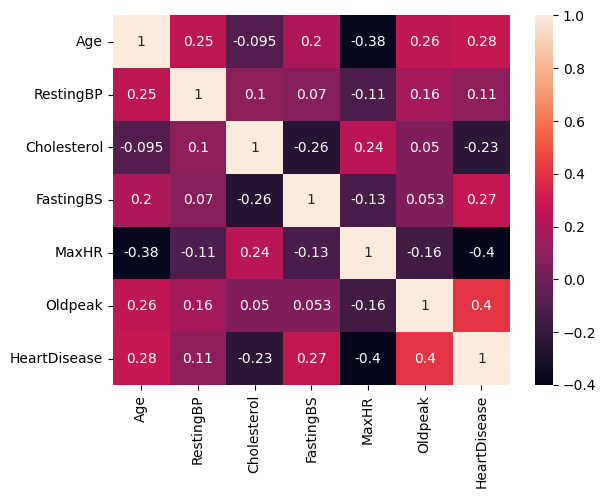

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [14]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

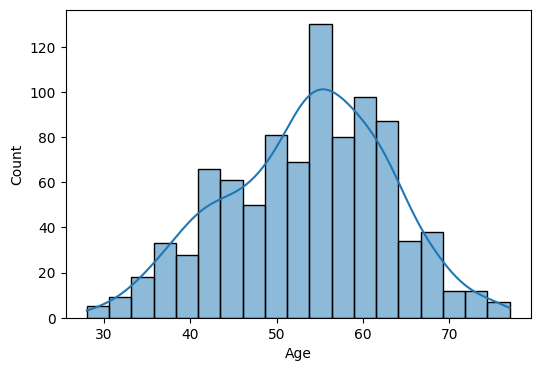

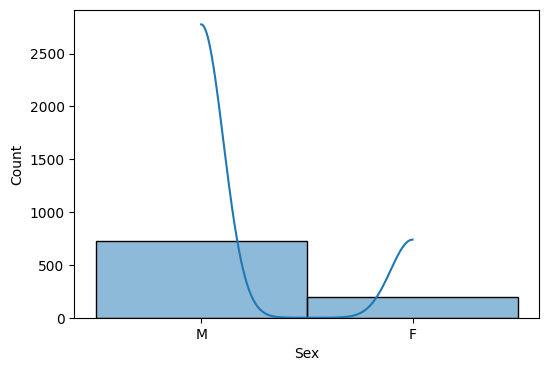

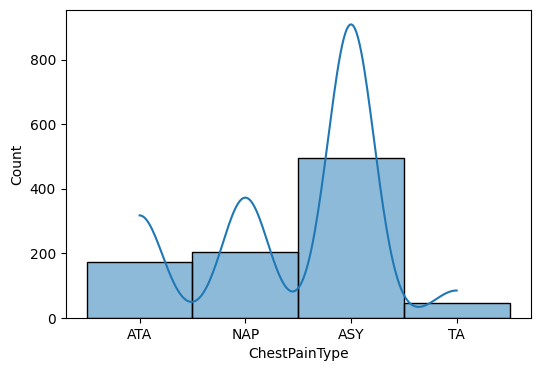

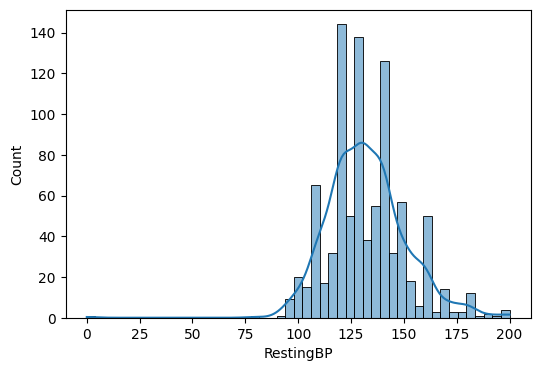

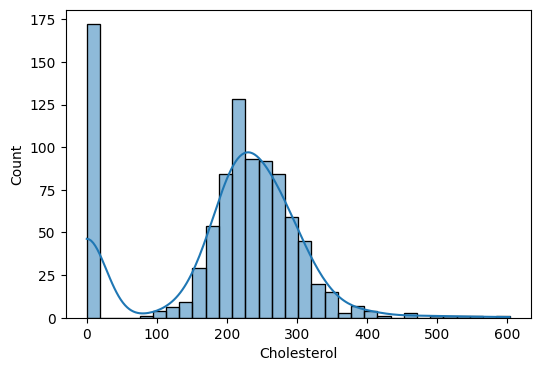

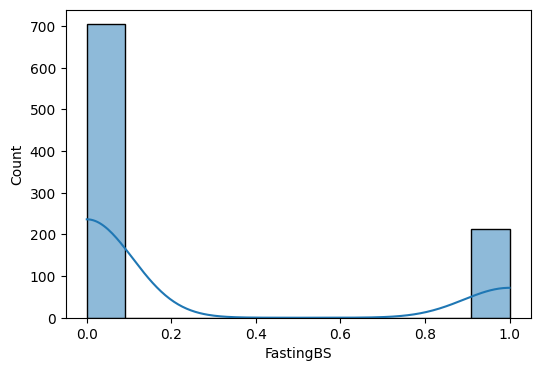

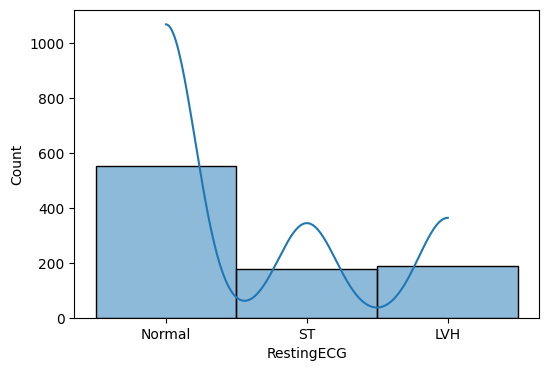

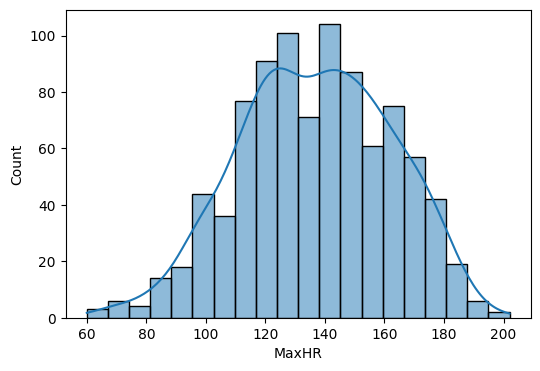

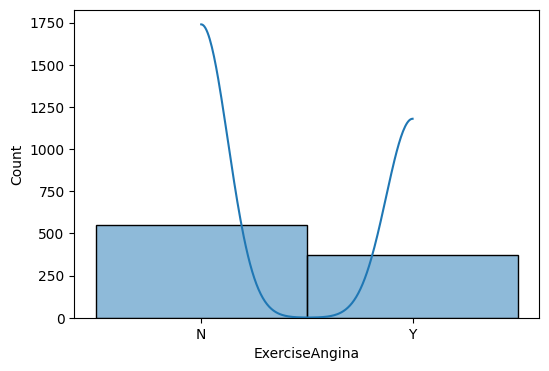

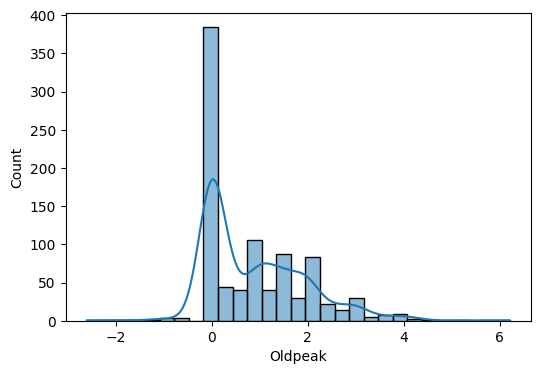

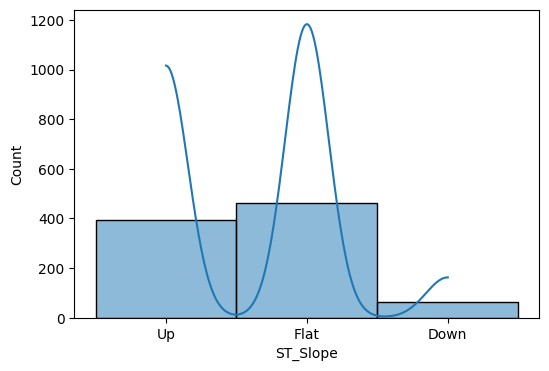

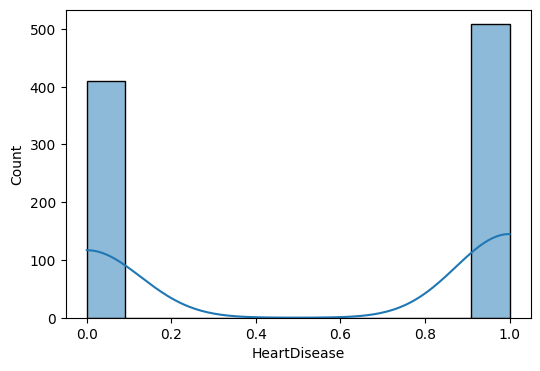

In [15]:
col=['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease']

for i in col:
  plt.figure(figsize=(6,4))
  sns.histplot(df[i],kde=True)

Chlestrol Resting BP has a bit of skewness

In [16]:
df["Sex"]

,Sex
0,M
1,F
2,M
3,F
4,M
...,...
913,M
914,M
915,M
916,F


In [17]:
df["Sex"]=df["Sex"].map({"M":1,"F":0})

In [18]:
df.rename(columns={"Sex":"is_Male"},inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   is_Male         918 non-null    int64  
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 86.2+ KB


In [20]:
df=pd.get_dummies(df,columns=['ChestPainType'],drop_first=True)

In [21]:
df.head()

,Age,is_Male,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,140,289,0,Normal,172,N,0.0,Up,0,True,False,False
1,49,0,160,180,0,Normal,156,N,1.0,Flat,1,False,True,False
2,37,1,130,283,0,ST,98,N,0.0,Up,0,True,False,False
3,48,0,138,214,0,Normal,108,Y,1.5,Flat,1,False,False,False
4,54,1,150,195,0,Normal,122,N,0.0,Up,0,False,True,False


In [22]:
df.columns

Index(['Age', 'is_Male', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG',
       'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA'],
      dtype='object')

In [23]:
df[["ChestPainType_ATA","ChestPainType_NAP","ChestPainType_TA"]]=df[["ChestPainType_ATA","ChestPainType_NAP","ChestPainType_TA"]].astype(int)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   is_Male            918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   RestingECG         918 non-null    object 
 6   MaxHR              918 non-null    int64  
 7   ExerciseAngina     918 non-null    object 
 8   Oldpeak            918 non-null    float64
 9   ST_Slope           918 non-null    object 
 10  HeartDisease       918 non-null    int64  
 11  ChestPainType_ATA  918 non-null    int64  
 12  ChestPainType_NAP  918 non-null    int64  
 13  ChestPainType_TA   918 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 100.5+ KB


In [25]:
df.head()

,Age,is_Male,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,140,289,0,Normal,172,N,0.0,Up,0,1,0,0
1,49,0,160,180,0,Normal,156,N,1.0,Flat,1,0,1,0
2,37,1,130,283,0,ST,98,N,0.0,Up,0,1,0,0
3,48,0,138,214,0,Normal,108,Y,1.5,Flat,1,0,0,0
4,54,1,150,195,0,Normal,122,N,0.0,Up,0,0,1,0


In [26]:
df["RestingECG"]

,RestingECG
0,Normal
1,Normal
2,ST
3,Normal
4,Normal
...,...
913,Normal
914,Normal
915,Normal
916,LVH


In [27]:
df=pd.get_dummies(df,columns=["RestingECG"],drop_first=True,dtype=int)

In [28]:
df.head()

,Age,is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,N,0.0,Up,0,1,0,0,1,0
1,49,0,160,180,0,156,N,1.0,Flat,1,0,1,0,1,0
2,37,1,130,283,0,98,N,0.0,Up,0,1,0,0,0,1
3,48,0,138,214,0,108,Y,1.5,Flat,1,0,0,0,1,0
4,54,1,150,195,0,122,N,0.0,Up,0,0,1,0,1,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   is_Male            918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   ExerciseAngina     918 non-null    object 
 7   Oldpeak            918 non-null    float64
 8   ST_Slope           918 non-null    object 
 9   HeartDisease       918 non-null    int64  
 10  ChestPainType_ATA  918 non-null    int64  
 11  ChestPainType_NAP  918 non-null    int64  
 12  ChestPainType_TA   918 non-null    int64  
 13  RestingECG_Normal  918 non-null    int64  
 14  RestingECG_ST      918 non-null    int64  
dtypes: float64(1), int64(12), object(2)
memory usage: 107.7+ KB


In [30]:
df["ExerciseAngina"].value_counts()

,count
ExerciseAngina,
N,547
Y,371


In [31]:
df["ExerciseAngina"]=df["ExerciseAngina"].map({
    "Y":1,
    "N":0
})

In [32]:
df.rename(columns={"ExerciseAngina":"is_ExerciseAngina"},inplace=True)

In [33]:
df.head()

,Age,is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,is_ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,0,0.0,Up,0,1,0,0,1,0
1,49,0,160,180,0,156,0,1.0,Flat,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,Up,0,1,0,0,0,1
3,48,0,138,214,0,108,1,1.5,Flat,1,0,0,0,1,0
4,54,1,150,195,0,122,0,0.0,Up,0,0,1,0,1,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   is_Male            918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   is_ExerciseAngina  918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   ST_Slope           918 non-null    object 
 9   HeartDisease       918 non-null    int64  
 10  ChestPainType_ATA  918 non-null    int64  
 11  ChestPainType_NAP  918 non-null    int64  
 12  ChestPainType_TA   918 non-null    int64  
 13  RestingECG_Normal  918 non-null    int64  
 14  RestingECG_ST      918 non-null    int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 107.7+ KB


In [35]:
df["ST_Slope"].value_counts()

,count
ST_Slope,
Flat,460
Up,395
Down,63


In [36]:
df=pd.get_dummies(df,columns=["ST_Slope"],drop_first=True,dtype=int)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   is_Male            918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   is_ExerciseAngina  918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ATA  918 non-null    int64  
 10  ChestPainType_NAP  918 non-null    int64  
 11  ChestPainType_TA   918 non-null    int64  
 12  RestingECG_Normal  918 non-null    int64  
 13  RestingECG_ST      918 non-null    int64  
 14  ST_Slope_Flat      918 non-null    int64  
 15  ST_Slope_Up        918 non-null    int64  
dtypes: float64(1), int64(15)
m

In [38]:
df.head()

,Age,is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,is_ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1


In [39]:
df.describe()

,Age,is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,is_ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,132.396514,198.799564,0.233115,136.809368,0.404139,0.887364,0.553377,0.188453,0.221133,0.050109,0.601307,0.193900,0.501089,0.430283
std,9.432617,0.407701,18.514154,109.384145,0.423046,25.460334,0.490992,1.066570,0.497414,0.391287,0.415236,0.218289,0.489896,0.395567,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,138.000000,0.000000,0.600000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [40]:
df.shape

(918, 16)

In [41]:
df.duplicated().sum()

np.int64(0)

#Checking Data to see if anything missed

In [42]:
df["Cholesterol"].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [43]:
df["RestingBP"].value_counts()

,count
RestingBP,
120,132
130,118
140,107
110,58
150,55
...,...
101,1
117,1
192,1


#BP & Cholestrol can never be zero

In [44]:
ch_mean=df.loc[df["Cholesterol"]!=0,"Cholesterol"].mean()

In [45]:
ch_mean

np.float64(244.6353887399464)

In [46]:
df["Cholesterol"]=df["Cholesterol"].replace(0,ch_mean)
df["Cholesterol"]=df["Cholesterol"].round(3)

In [47]:
bp_mean=df["RestingBP"].loc[df["RestingBP"]!=0,].mean()

In [48]:
bp_mean

np.float64(132.54089422028352)

In [49]:
df["RestingBP"]=df["RestingBP"].replace(0,ch_mean)
df["RestingBP"]=df["RestingBP"].round(3)

<Axes: xlabel='Cholesterol', ylabel='Count'>

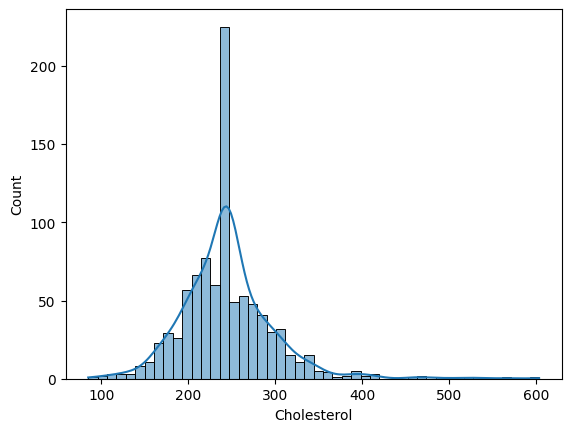

In [50]:
sns.histplot(df["Cholesterol"],kde=True)

<Axes: xlabel='RestingBP', ylabel='Count'>

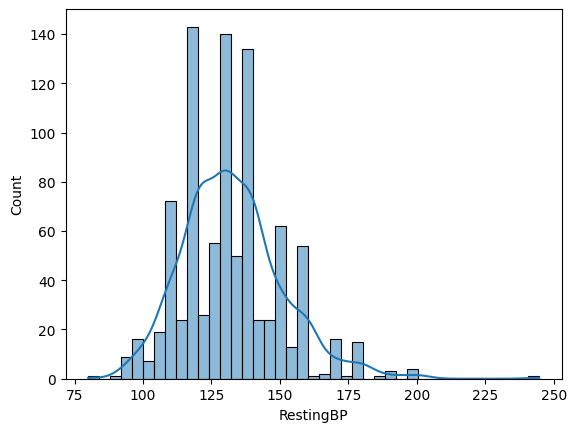

In [51]:
sns.histplot(df["RestingBP"],kde=True)

In [52]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[df.columns]=scaler.fit_transform(df[df.columns])

<Axes: xlabel='Age', ylabel='Cholesterol'>

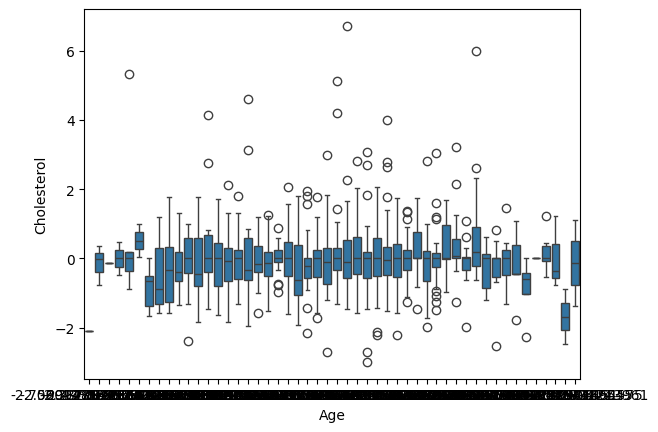

In [53]:
sns.boxplot(x=df["Age"],y=df["Cholesterol"])

#Standardize data then select which to keep and drop

<Axes: >

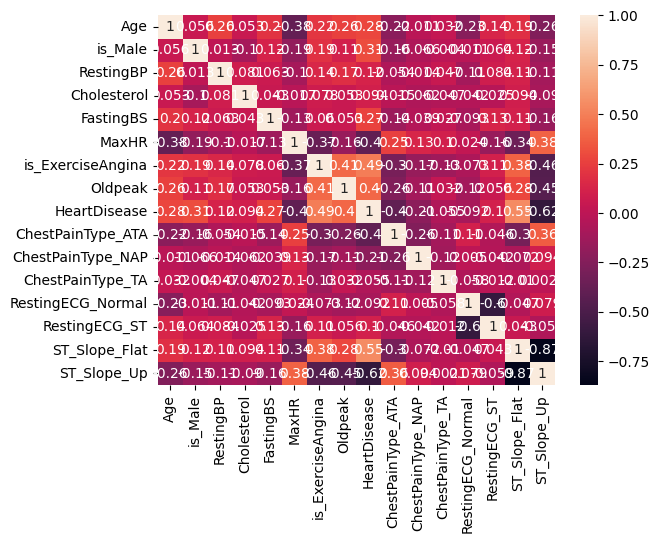

In [54]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#Regression--> Predict.
#Corr and Variance--> Pearson Correlatiom
# ANNOVA Testing

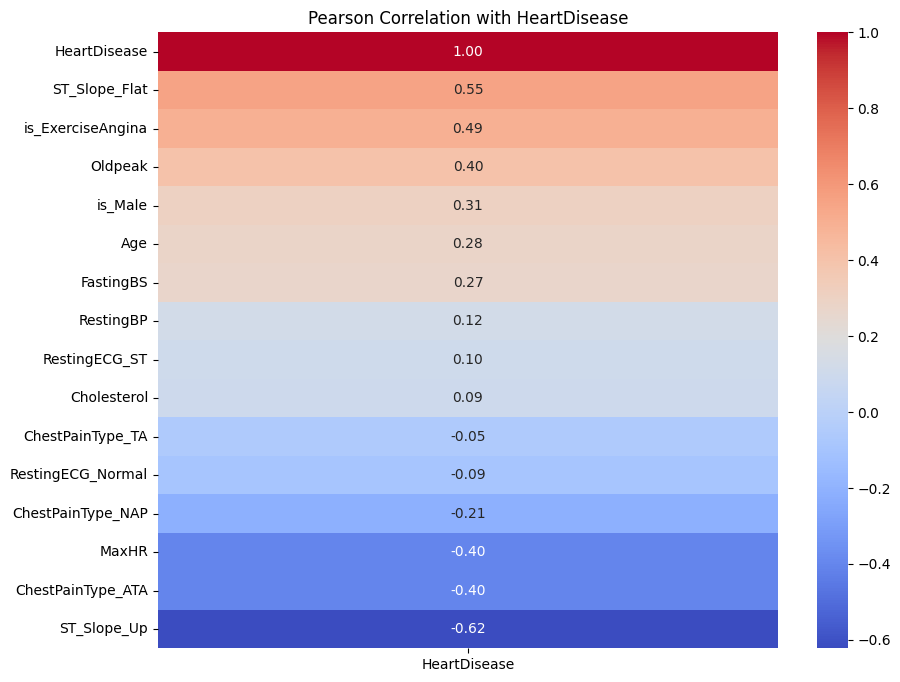

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True)[["HeartDisease"]].sort_values(by="HeartDisease", ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation with HeartDisease')
plt.show()

### Variance Analysis
Low Variance== mostly drop.

In [56]:
variance = df.var().sort_values(ascending=True)
print("Feature Variances:\n", variance)

Feature Variances:
 FastingBS            1.001091
is_ExerciseAngina    1.001091
Oldpeak              1.001091
Age                  1.001091
MaxHR                1.001091
Cholesterol          1.001091
ST_Slope_Up          1.001091
RestingBP            1.001091
ST_Slope_Flat        1.001091
RestingECG_Normal    1.001091
is_Male              1.001091
HeartDisease         1.001091
RestingECG_ST        1.001091
ChestPainType_NAP    1.001091
ChestPainType_TA     1.001091
ChestPainType_ATA    1.001091
dtype: float64


### ANOVA Testing (F-statistic)


In [57]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
f_selector = SelectKBest(f_classif, k='all')
f_selector.fit(X, y)
f_scores = pd.DataFrame({'Feature': X.columns, 'F-Score': f_selector.scores_, 'P-Value': f_selector.pvalues_})
f_scores = f_scores.sort_values(by='P-Value', ascending=True).reset_index(drop=True)

print("ANOVA F-Scores and P-Values for Features:")
display(f_scores)

ANOVA F-Scores and P-Values for Features:


,Feature,F-Score,P-Value
0,ST_Slope_Up,578.505658,1.796659e-99
1,ST_Slope_Flat,405.911473,5.171766e-75
2,is_ExerciseAngina,296.144771,1.013018e-57
3,Oldpeak,178.615120,2.390772e-37
4,ChestPainType_ATA,176.482905,5.868475e-37
5,MaxHR,174.913585,1.137786e-36
6,is_Male,94.253184,2.821898e-21
7,Age,79.160779,3.007953e-18
8,FastingBS,70.478543,1.753598e-16
9,ChestPainType_NAP,43.517481,7.096217e-11


In [58]:
df = df.drop('ChestPainType_TA', axis=1)

In [59]:
display(df.head())

,Age,is_Male,RestingBP,Cholesterol,FastingBS,MaxHR,is_ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.515952,0.399697,0.832530,-0.551341,1.382928,-0.823556,-0.832432,-1.113115,2.075177,-0.532838,0.814275,-0.490449,-1.002181,1.150674
1,-0.478484,-1.938163,1.489235,-1.212921,-0.551341,0.754157,-0.823556,0.105664,0.898380,-0.481887,1.876744,0.814275,-0.490449,0.997824,-0.869056
2,-1.751359,0.515952,-0.145072,0.719937,-0.551341,-1.525138,-0.823556,-0.832432,-1.113115,2.075177,-0.532838,-1.228087,2.038947,-1.002181,1.150674
3,-0.584556,-1.938163,0.290743,-0.574890,-0.551341,-1.132156,1.214246,0.574711,0.898380,-0.481887,-0.532838,0.814275,-0.490449,0.997824,-0.869056
4,0.051881,0.515952,0.944466,-0.931437,-0.551341,-0.581981,-0.823556,-0.832432,-1.113115,-0.481887,1.876744,0.814275,-0.490449,-1.002181,1.150674


In [60]:
df.to_csv("Cleaned_Heart.csv")